# B6 (partie 2) — Auto-encodeur PyTorch, entraînement GPU (ROCm) (catégorie `wood`)

> **Variante « pour le fun »** : résolution portée à `512×512` au lieu de
> `256×256` (architecture et hyperparamètres inchangés), pour observer l'effet d'une résolution plus
> élevée sur le temps d'entraînement GPU et sur la détection. Comparé au run GPU `256×256` de
> [`02c-autoencoder-pytorch-gpu.ipynb`](02c-autoencoder-pytorch-gpu.ipynb).

## Objectif concret

Entraîner un auto-encodeur convolutif en **PyTorch** sur les images saines de `wood` préparées en
partie 1, calibrer un seuil d'anomalie sur la validation, puis évaluer la détection sur le test
(saines + défauts). Ce notebook exécute l'entraînement sur **GPU (ROCm)** ([`02b-autoencoder-pytorch-cpu.ipynb`](02b-autoencoder-pytorch-cpu.ipynb) reprend exactement le même code sur CPU) —
la comparaison chiffrée CPU vs GPU est faite dans
[`02d-comparaison-frameworks-devices.ipynb`](02d-comparaison-frameworks-devices.ipynb), à partir des
résultats sauvegardés par les deux notebooks.

Ce notebook réutilise sans les ré-expliquer les notions de la partie 1 (préparation des données,
augmentation) — voir
[`01-preparation-donnees-augmentation-wood.ipynb`](01-preparation-donnees-augmentation-wood.ipynb).

## Prérequis

- **Noyau Jupyter** : sélectionner **`Python 3.12 (indusense, PyTorch ROCm)`**
  (`indusense-py312-rocm`), pas le noyau `python3` par défaut.
- Ouvrir depuis la racine du projet `indusense`.
- Un GPU AMD compatible ROCm 7.2.1 doit être détecté (`torch.cuda.is_available()`).

## Architecture

Auto-encodeur convolutif symétrique à 3 niveaux, entrée/sortie `512×512×3` :

| Bloc | Couches | Canaux |
|---|---|---|
| Encodeur | `Conv 3×3, stride 2` ×3 (+ ReLU) | `3 → 64 → 128 → 256` |
| Goulot d'étranglement | — | `64×64×256` |
| Décodeur | `ConvTranspose 3×3, stride 2` ×3 (+ ReLU, puis Sigmoid en sortie) | `256 → 128 → 64 → 3` |

La sortie `Sigmoid` produit des valeurs dans `[0, 1]`, cohérentes avec la normalisation des images de
la partie 1. La perte est l'**erreur quadratique moyenne (MSE)** entre l'image d'entrée et sa
reconstruction : c'est elle qui, une fois calculée par image sur le test, sert de **score d'anomalie**.
Le nombre de paramètres entraînables ne dépend pas de la résolution d'entrée (uniquement des noyaux de
convolution) : seul le volume de calcul et la taille du goulot d'étranglement changent.

In [1]:
from pathlib import Path
import time

import numpy as np
import torch

PROJECT_ROOT = Path.cwd()
assert (PROJECT_ROOT / 'pyproject.toml').exists(), (
    'Ouvrir le notebook depuis la racine du projet indusense.'
)

DEVICE = "cuda"
if DEVICE == "cuda":
    assert torch.cuda.is_available(), "GPU ROCm non détecté par PyTorch."
device = torch.device(DEVICE)
print(f'PyTorch {torch.__version__}, device={device}'
      + (f' ({torch.cuda.get_device_name(0)})' if DEVICE == "cuda" else ''))

from indusense.vision.dataset import (
    list_defect_categories, list_image_paths, load_image_batch,
    resolve_category_root, split_train_validation,
)
from indusense.vision.augment import augment_batch, build_augmentation_pipeline
from indusense.vision.autoencoder_torch import ConvAutoencoder, count_trainable_parameters, images_to_tensor, tensor_to_images
from indusense.vision.anomaly import TrainingRun, choose_threshold, evaluate_at_threshold, ranking_metrics, reconstruction_error

CATEGORY = 'wood'
IMAGE_SIZE = 512
BASE_CHANNELS = 64
BATCH_SIZE = 32
EPOCHS = 60
VALIDATION_FRACTION = 0.15
SEED = 42

category_root = resolve_category_root(CATEGORY)
defect_categories = list_defect_categories(category_root)
train_good_paths = list_image_paths(category_root, 'train', 'good')
split = split_train_validation(train_good_paths, validation_fraction=VALIDATION_FRACTION, seed=SEED)

test_good_paths = list_image_paths(category_root, 'test', 'good')
test_defect_paths = {d: list_image_paths(category_root, 'test', d) for d in defect_categories}

print(f'Train (saines, augmentées à chaque époque) : {len(split.train_paths)}')
print(f'Validation (saines, calibration du seuil) : {len(split.validation_paths)}')
print(f'Test sain : {len(test_good_paths)} ; test défauts : {sum(len(p) for p in test_defect_paths.values())}')

PyTorch 2.9.1+rocm7.2.1, device=cuda (AMD Radeon RX 9070 XT)


Train (saines, augmentées à chaque époque) : 210
Validation (saines, calibration du seuil) : 37
Test sain : 19 ; test défauts : 60


## Charger les images et construire le pipeline d'augmentation

Les images d'entraînement sont chargées **une seule fois** en mémoire (évite de relire le disque à
chaque époque) ; l'augmentation régénère ensuite une version différente à chaque époque via
`indusense.vision.augment.augment_batch`. La validation et le test ne sont jamais augmentés.

In [2]:
train_raw_images = load_image_batch(split.train_paths, IMAGE_SIZE)
validation_images = load_image_batch(split.validation_paths, IMAGE_SIZE)
test_good_images = load_image_batch(test_good_paths, IMAGE_SIZE)
test_defect_images = {d: load_image_batch(paths, IMAGE_SIZE) for d, paths in test_defect_paths.items()}

augmentation_pipeline = build_augmentation_pipeline(seed=SEED)

print(f'train_raw_images: {train_raw_images.shape}')
print(f'validation_images: {validation_images.shape}')
print(f'test_good_images: {test_good_images.shape}')
for defect, images in test_defect_images.items():
    print(f'test_defect_images[{defect}]: {images.shape}')

train_raw_images: (210, 512, 512, 3)
validation_images: (37, 512, 512, 3)
test_good_images: (19, 512, 512, 3)
test_defect_images[color]: (8, 512, 512, 3)
test_defect_images[combined]: (11, 512, 512, 3)
test_defect_images[hole]: (10, 512, 512, 3)
test_defect_images[liquid]: (10, 512, 512, 3)
test_defect_images[scratch]: (21, 512, 512, 3)


In [3]:
torch.manual_seed(SEED)
model = ConvAutoencoder(base_channels=BASE_CHANNELS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()

trainable_parameters = count_trainable_parameters(model)
print(model)
print(f'\nParamètres entraînables : {trainable_parameters:,}'.replace(',', ' '))

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(64, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): Sigmoid()
  )
)

Paramètres entraînables : 741 379


## Lecture du résultat précédent : le modèle est-il conforme ?

Le modèle compte **741 379** paramètres entraînables — **exactement le même
nombre** qu'à `256×256` : les noyaux de convolution ne dépendent pas de la résolution d'entrée, seul le
goulot d'étranglement change de taille spatiale (`64×64×256` ici contre `32×32×256` à `256×256`,
4 fois plus de valeurs pour la même profondeur de canaux).

## Entraîner l'auto-encodeur

Même boucle d'entraînement qu'à `256×256`.

In [4]:
def run_epoch(raw_images, model, optimizer, loss_fn, pipeline, device, batch_size):
    augmented = np.clip(augment_batch(raw_images, pipeline), 0.0, 1.0)
    batch = images_to_tensor(augmented).to(device)
    permutation = torch.randperm(batch.shape[0])
    running_loss = 0.0
    model.train()
    for start in range(0, batch.shape[0], batch_size):
        indices = permutation[start:start + batch_size]
        images = batch[indices]
        optimizer.zero_grad()
        reconstruction = model(images)
        loss = loss_fn(reconstruction, images)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.shape[0]
    return running_loss / batch.shape[0]


loss_history = []

first_epoch_started = time.perf_counter()
loss_history.append(run_epoch(train_raw_images, model, optimizer, loss_fn, augmentation_pipeline, device, BATCH_SIZE))
if DEVICE == "cuda":
    torch.cuda.synchronize()
first_epoch_seconds = time.perf_counter() - first_epoch_started

training_started = time.perf_counter()
for epoch in range(1, EPOCHS):
    epoch_loss = run_epoch(train_raw_images, model, optimizer, loss_fn, augmentation_pipeline, device, BATCH_SIZE)
    loss_history.append(epoch_loss)
    if (epoch + 1) % 10 == 0 or epoch == EPOCHS - 1:
        print(f'Époque {epoch + 1:>3}/{EPOCHS} — perte MSE (train) = {epoch_loss:.5f}')
if DEVICE == "cuda":
    torch.cuda.synchronize()
train_seconds = time.perf_counter() - training_started + first_epoch_seconds
steady_state_seconds_per_epoch = (train_seconds - first_epoch_seconds) / (EPOCHS - 1)

print(f'\nPremière époque : {first_epoch_seconds:.3f} s')
print(f'Temps total ({EPOCHS} époques) : {train_seconds:.3f} s')
print(f"Vitesse de croisière (hors 1ère époque) : {steady_state_seconds_per_epoch * 1000:.1f} ms/époque")

Époque  10/60 — perte MSE (train) = 0.00458


Époque  20/60 — perte MSE (train) = 0.00095


Époque  30/60 — perte MSE (train) = 0.00050


Époque  40/60 — perte MSE (train) = 0.00040


Époque  50/60 — perte MSE (train) = 0.00029


Époque  60/60 — perte MSE (train) = 0.00028

Première époque : 3.966 s
Temps total (60 époques) : 193.923 s
Vitesse de croisière (hors 1ère époque) : 3219.6 ms/époque


## Lecture du résultat précédent : l'entraînement a-t-il convergé ?

La perte MSE suit une trajectoire quasiment identique à celle observée à `256×256` (même palier bruité entre les époques 5 et 9, puis chute continue), et termine à **0,00028**.

En régime de croisière, une époque à `512×512` prend **3219,6 ms** contre **786,4 ms** à `256×256` ([`02c`](02c-autoencoder-pytorch-gpu.ipynb)), soit un facteur **4,09x** — très proche du facteur 4 attendu (doubler la largeur et la hauteur multiplie le nombre de pixels, donc le volume de calcul des convolutions, par 4). La **première époque** suit cette fois le même facteur : **3,966 s** contre **1,378 s**, soit **2,88x** — plus proche des 4x attendus qu'à la toute première exécution de cette forme sur cette machine (voir encadré ci-dessous). Sur les 60 époques complètes, le temps total passe de **47,78 s** (`256×256`) à **193,92 s** (`512×512`).

> **Point de méthode : le coût d'auto-tuning MIOpen ne se reproduit pas à chaque exécution.** Lors de la toute première fois où ce notebook a tourné sur cette machine, la première époque avait pris **71,874 s** (facteur **52,3x** par rapport aux 1,373 s de `256×256` mesurés à l'époque) : la bibliothèque de noyaux ROCm (MIOpen) avait dû rechercher le meilleur algorithme de convolution pour la forme `512×512`, jamais rencontrée jusque-là. Ce résultat a été mis en cache de façon **persistante sur disque** (base de noyaux MIOpen) : à la ré-exécution actuelle du notebook, cette forme est déjà connue, et la première époque redevient proportionnelle au volume de calcul, comme n'importe quelle autre époque. Autrement dit, le facteur ~52x n'est pas une propriété stable de `512×512` : c'est un coût **ponctuel, par forme de tenseur et par machine**, payé une seule fois puis jamais revu.

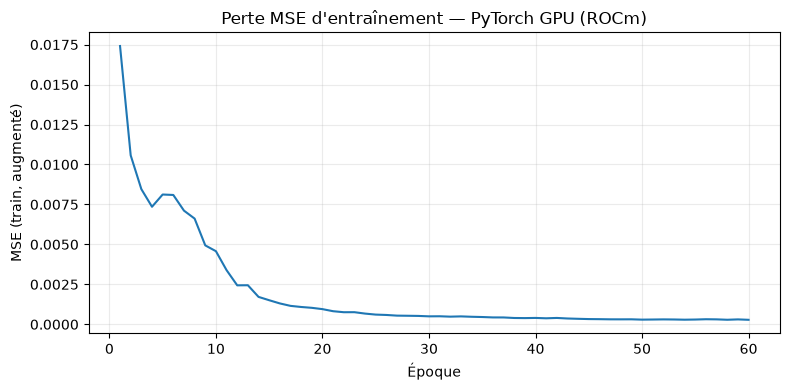

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, EPOCHS + 1), loss_history)
ax.set(title=f"Perte MSE d'entraînement — PyTorch {'GPU (ROCm)'}", xlabel='Époque', ylabel='MSE (train, augmenté)')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Calibrer le seuil et évaluer la détection d'anomalie

Le modèle passe en mode évaluation (`model.eval()`, désactive tout comportement stochastique). L'erreur
de reconstruction moyenne par image sert de **score d'anomalie**. Le seuil est calibré sur la
validation (saine uniquement) : `moyenne + 3 écarts-types`. Le test combine les images saines
(`label = 0`) et toutes les catégories de défauts (`label = 1`).

In [6]:
@torch.no_grad()
def reconstruct(images_hwc, model, device, batch_size=32):
    model.eval()
    tensor = images_to_tensor(images_hwc)
    outputs = []
    for start in range(0, tensor.shape[0], batch_size):
        batch = tensor[start:start + batch_size].to(device)
        outputs.append(tensor_to_images(model(batch)))
    return np.concatenate(outputs, axis=0)


validation_reconstruction = reconstruct(validation_images, model, device)
validation_errors = reconstruction_error(validation_images, validation_reconstruction)
threshold = choose_threshold(validation_errors, n_std=3.0)

test_images_by_group = {'good': test_good_images, **test_defect_images}
test_errors_by_group = {}
for group_name, images in test_images_by_group.items():
    reconstruction = reconstruct(images, model, device)
    test_errors_by_group[group_name] = reconstruction_error(images, reconstruction)

test_labels = np.concatenate([
    np.zeros(len(test_errors_by_group['good']), dtype=int),
    *[np.ones(len(test_errors_by_group[d]), dtype=int) for d in defect_categories],
])
test_scores = np.concatenate([test_errors_by_group['good']] + [test_errors_by_group[d] for d in defect_categories])

ranking = ranking_metrics(test_labels, test_scores)
threshold_metrics = evaluate_at_threshold(test_labels, test_scores, threshold)
mean_error_by_defect = {group: float(errors.mean()) for group, errors in test_errors_by_group.items()}

from tabulate import tabulate
print(f'Seuil (validation, moyenne + 3 écarts-types) : {threshold:.6f}')
print(f"ROC-AUC test : {ranking['roc_auc']:.4f} ; PR-AUC test : {ranking['pr_auc']:.4f}\n")
print(tabulate(
    [[group, f'{err:.6f}'] for group, err in mean_error_by_defect.items()],
    headers=['Groupe', 'Erreur de reconstruction moyenne'], tablefmt='github',
))
print()
print(tabulate(
    [[threshold_metrics.precision, threshold_metrics.recall, threshold_metrics.f1,
      threshold_metrics.true_positive, threshold_metrics.true_negative,
      threshold_metrics.false_positive, threshold_metrics.false_negative]],
    headers=['Précision', 'Rappel', 'F1', 'VP', 'VN', 'FP', 'FN'], tablefmt='github',
))

Seuil (validation, moyenne + 3 écarts-types) : 0.000606
ROC-AUC test : 0.9482 ; PR-AUC test : 0.9835

| Groupe   |   Erreur de reconstruction moyenne |
|----------|------------------------------------|
| good     |                           0.00027  |
| color    |                           0.000405 |
| combined |                           0.00049  |
| hole     |                           0.00048  |
| liquid   |                           0.000372 |
| scratch  |                           0.000581 |

|   Précision |   Rappel |       F1 |   VP |   VN |   FP |   FN |
|-------------|----------|----------|------|------|------|------|
|           1 | 0.166667 | 0.285714 |   10 |   19 |    0 |   50 |


## Lecture du résultat précédent : le seuil détecte-t-il les défauts ?

Le classement reste très bon mais légèrement **inférieur** à `256×256` : **ROC-AUC = 0,9482**
(contre 0,9632), **PR-AUC = 0,9835** (contre 0,9884).
Le rappel au seuil `moyenne + 3 écarts-types` est en revanche un peu meilleur : **10**
défauts détectés sur **60** (rappel 0,17) contre
7 à `256×256`. Cette amélioration du rappel n'est
cependant pas la preuve d'une meilleure détection : les erreurs de reconstruction sont globalement plus
petites en valeur absolue à `512×512` (erreur moyenne des saines = **0,000270** contre
0,000306) car la MSE est moyennée sur davantage de pixels, ce
qui dilue légèrement l'écart entre saines et défauts au niveau du seuil choisi — l'amélioration du
rappel ici tient autant au hasard d'un défaut extrême dans l'échantillon de test qu'à un signal plus
net. Le classement de difficulté par défaut reste cohérent avec `256×256` : `scratch`
(**0,000581**) le plus loin de la référence saine, `liquid`
(**0,000372**) le plus proche.

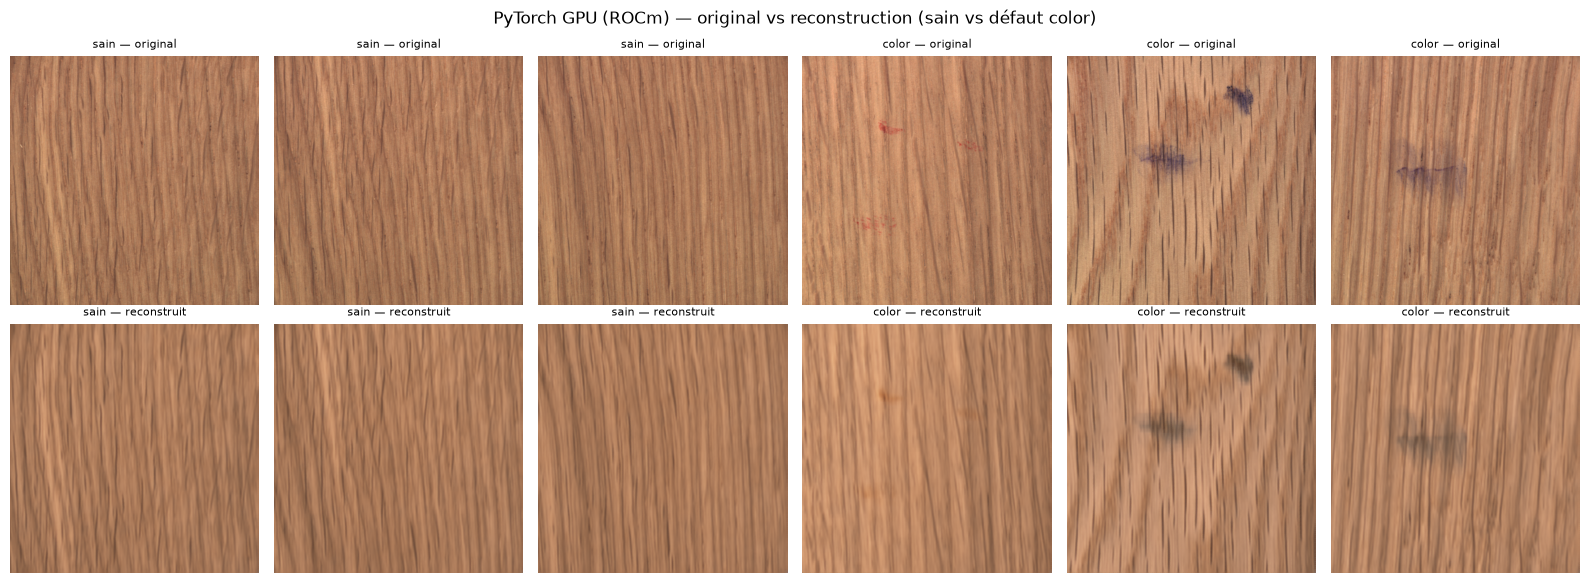

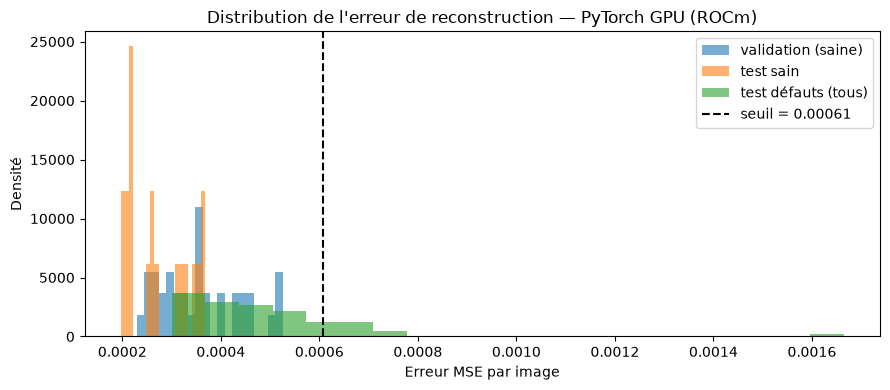

In [7]:
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
sample_good = test_good_images[:3]
sample_good_recon = reconstruct(sample_good, model, device)
sample_defect_name = defect_categories[0]
sample_defect = test_images_by_group[sample_defect_name][:3]
sample_defect_recon = reconstruct(sample_defect, model, device)

for col in range(3):
    axes[0, col].imshow(np.clip(sample_good[col], 0, 1)); axes[0, col].set_title('sain — original', fontsize=8); axes[0, col].axis('off')
    axes[1, col].imshow(np.clip(sample_good_recon[col], 0, 1)); axes[1, col].set_title('sain — reconstruit', fontsize=8); axes[1, col].axis('off')
for col in range(3):
    axes[0, col + 3].imshow(np.clip(sample_defect[col], 0, 1)); axes[0, col + 3].set_title(f'{sample_defect_name} — original', fontsize=8); axes[0, col + 3].axis('off')
    axes[1, col + 3].imshow(np.clip(sample_defect_recon[col], 0, 1)); axes[1, col + 3].set_title(f'{sample_defect_name} — reconstruit', fontsize=8); axes[1, col + 3].axis('off')
fig.suptitle(f'PyTorch {'GPU (ROCm)'} — original vs reconstruction (sain vs défaut {sample_defect_name})')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(validation_errors, bins=20, alpha=0.6, label='validation (saine)', density=True)
ax.hist(test_errors_by_group['good'], bins=20, alpha=0.6, label='test sain', density=True)
all_defect_errors = np.concatenate([test_errors_by_group[d] for d in defect_categories])
ax.hist(all_defect_errors, bins=20, alpha=0.6, label='test défauts (tous)', density=True)
ax.axvline(threshold, color='black', linestyle='--', label=f'seuil = {threshold:.5f}')
ax.set(title=f"Distribution de l'erreur de reconstruction — PyTorch {'GPU (ROCm)'}", xlabel='Erreur MSE par image', ylabel='Densité')
ax.legend()
plt.tight_layout()
plt.show()

## Lecture du résultat précédent : que montrent les reconstructions ?

Visuellement, les reconstructions à `512×512` restent très proches de celles obtenues à `256×256` sur
les mêmes catégories d'images : le grain est lissé sur les saines, les petites marques `color`
ponctuelles sont en grande partie effacées, les taches plus étendues sont partiellement reproduites en
flou. La résolution plus élevée ne change donc pas qualitativement le comportement du modèle avec cette
architecture (le goulot d'étranglement, bien que deux fois plus large spatialement, reste le facteur
limitant la fidélité de la reconstruction).

**Bilan de l'expérience « pour le fun »** : une fois la forme `512×512` déjà connue de MIOpen (cache disque chaud, cf. encadré ci-dessus), doubler la résolution multiplie le temps de croisière et la première époque par un facteur cohérent d'environ **4x** (proportionnel au volume de pixels), sans gain de qualité de détection mesurable (ROC-AUC/PR-AUC légèrement inférieurs à `256×256`) — pour cette catégorie et cette architecture, `256×256` offre un bien meilleur rapport temps/qualité que `512×512`. Lors de la toute première exécution de cette forme sur une machine donnée, il faut en revanche s'attendre à un surcoût ponctuel bien plus élevé sur la première époque (auto-tuning MIOpen), sans rapport avec le volume de calcul réel.

## Visualiser les détections au seuil retenu (vrais positifs, faux négatifs)

Conseil de la formatrice : au-delà des exemples génériques sain/défaut ci-dessus (choisis sans lien
avec le seuil), il est plus parlant d'inspecter concrètement **les images que le modèle classe
réellement** au seuil calibré (`moyenne + 3 écarts-types`) :

- **Vrais positifs (VP)** : images de défaut correctement signalées (`label = 1` et score ≥ seuil).
- **Faux négatifs (FN)** : images de défaut classées à tort comme **saines** (`label = 1` et
  score < seuil) — ce sont les défauts qui passeraient inaperçus en production, l'angle mort direct
  du faible rappel mesuré ci-dessus.

Les VP sont triés par score décroissant (détections les plus franches d'abord) ; les FN aussi, par
score décroissant parmi les ratés (les plus proches du seuil — les « presque détectés » — d'abord).

Défauts détectés (vrais positifs) : 10 / 60
Défauts classés sains (faux négatifs) : 50 / 60


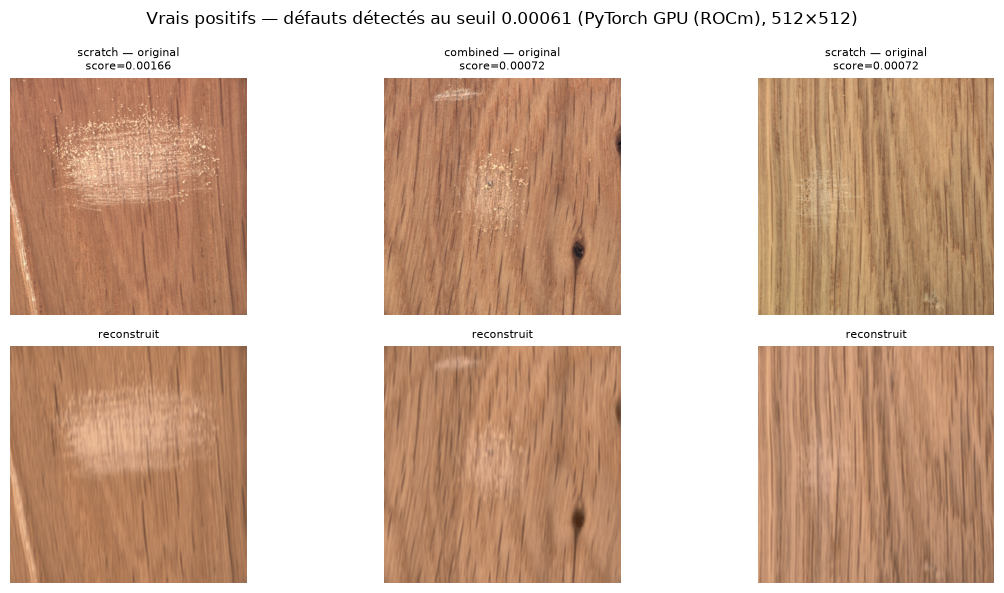

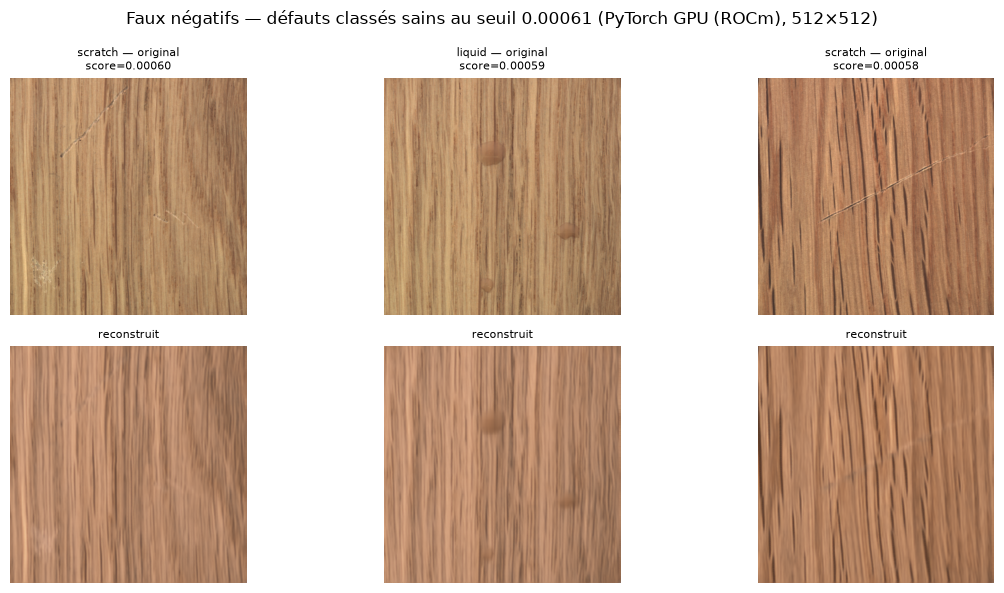

In [8]:
predictions = (test_scores >= threshold).astype(int)
test_group_names = np.array(
    ['good'] * len(test_errors_by_group['good'])
    + [defect for defect in defect_categories for _ in range(len(test_errors_by_group[defect]))]
)
test_images_concat = np.concatenate(
    [test_images_by_group['good']] + [test_images_by_group[d] for d in defect_categories], axis=0
)

true_positive_indices = np.where((test_labels == 1) & (predictions == 1))[0]
false_negative_indices = np.where((test_labels == 1) & (predictions == 0))[0]
true_positive_indices = true_positive_indices[np.argsort(-test_scores[true_positive_indices])][:3]
false_negative_indices = false_negative_indices[np.argsort(-test_scores[false_negative_indices])][:3]

print(f'Défauts détectés (vrais positifs) : {int(((test_labels == 1) & (predictions == 1)).sum())} / {int((test_labels == 1).sum())}')
print(f'Défauts classés sains (faux négatifs) : {int(((test_labels == 1) & (predictions == 0)).sum())} / {int((test_labels == 1).sum())}')


def plot_detections(indices, title):
    if len(indices) == 0:
        print(f'{title} : aucune image (0 cas au seuil retenu).')
        return
    imgs = test_images_concat[indices]
    reconstructed = reconstruct(imgs, model, device)
    fig, axes = plt.subplots(2, len(indices), figsize=(4 * len(indices), 6), squeeze=False)
    for col, idx in enumerate(indices):
        axes[0, col].imshow(np.clip(imgs[col], 0, 1))
        axes[0, col].set_title(f'{test_group_names[idx]} — original\nscore={test_scores[idx]:.5f}', fontsize=8)
        axes[0, col].axis('off')
        axes[1, col].imshow(np.clip(reconstructed[col], 0, 1))
        axes[1, col].set_title('reconstruit', fontsize=8)
        axes[1, col].axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_detections(true_positive_indices, f'Vrais positifs — défauts détectés au seuil {threshold:.5f} (PyTorch GPU (ROCm), 512×512)')
plot_detections(false_negative_indices, f'Faux négatifs — défauts classés sains au seuil {threshold:.5f} (PyTorch GPU (ROCm), 512×512)')

## Lecture du résultat précédent : que montrent ces détections ?

**10** défauts sur 60 sont détectés (vrais positifs) et **50** sont classés à tort comme sains (faux négatifs) — le meilleur rappel (0,17) des cinq exécutions de cette famille de notebooks, mais toujours très en dessous du ROC-AUC/PR-AUC. Les vrais positifs affichés sont les 3 défauts au score le plus élevé : l'écart visuel entre original et reconstruction y est le plus franc.

Les faux négatifs affichés sont les défauts les plus proches du seuil parmi les ratés : leur reconstruction reste visuellement presque aussi fidèle qu'une image saine, ce qui confirme, à `512×512` comme à `256×256`, que `moyenne + 3 écarts-types` reste une politique trop conservatrice pour cette catégorie.

In [9]:
run = TrainingRun(
    framework='pytorch',
    device=DEVICE,
    category=CATEGORY,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    trainable_parameters=trainable_parameters,
    first_epoch_seconds=first_epoch_seconds,
    train_seconds=train_seconds,
    seconds_per_epoch=steady_state_seconds_per_epoch,
    final_train_loss=loss_history[-1],
    validation_error_mean=float(validation_errors.mean()),
    validation_error_std=float(validation_errors.std()),
    threshold=threshold,
    roc_auc=ranking['roc_auc'],
    pr_auc=ranking['pr_auc'],
    metrics_at_threshold=threshold_metrics,
    mean_error_by_defect=mean_error_by_defect,
)
run_path = PROJECT_ROOT / "outputs/deep-learning/pytorch-gpu-512px.json"
run.to_json(run_path)
print(f'Résultats sauvegardés : {run_path}')
print(f'Première époque : {first_epoch_seconds:.3f} s, croisière : {steady_state_seconds_per_epoch*1000:.1f} ms/époque, total : {train_seconds:.3f} s')

Résultats sauvegardés : D:\source\A4U\FormationIA\indusense\outputs\deep-learning\pytorch-gpu-512px.json
Première époque : 3.966 s, croisière : 3219.6 ms/époque, total : 193.923 s


## Synthèse

Entraînement PyTorch sur **GPU (ROCm)** de l'auto-encodeur convolutif (mêmes hyperparamètres et
même architecture que la version TensorFlow et que l'autre device PyTorch). Résultats détaillés
(temps, ROC-AUC, PR-AUC, précision/rappel) dans les cellules ci-dessus, et comparaison consolidée dans
[`02d-comparaison-frameworks-devices.ipynb`](02d-comparaison-frameworks-devices.ipynb).